### Importing Required Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

### Download the dataset to this lab environment

In [ ]:
import requests
import os

def download_data(url ,filename):
    # os.makedirs("data", exist_ok=True)
    filepath = os.path.join("../data/raw/", filename)
    response = requests.get(url)
    if response.status_code == 200:
        with open(filepath, 'wb') as file:
            file.write(response.content)
        print("Data downloaded and saved successfully.")
    else:
        print("Failed to download data.")

In [ ]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'

In [16]:
download_data(filepath,'medical_insurance_dataset.csv')

Data downloaded and saved successfully.


In [ ]:
RAW_DATA_LOC = '../data/raw/medical_insurance_dataset.csv'
PRO_DATA_LOC = '../data/processed/'

In [37]:
df = pd.read_csv(RAW_DATA_LOC)

In [39]:
df.head(10)

,19,1,27.9,0,1.1,3,16884.924
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160
5,46,1,33.440,1,0,4,8240.58960
6,37,1,27.740,3,0,1,7281.50560
7,37,2,29.830,2,0,2,6406.41070
8,60,1,25.840,0,0,1,28923.13692
9,25,2,26.220,0,0,2,2721.32080


| Parameter |Description| Content type |
|---|----|---|
|age| Age in years| integer |
|gender| Male or Female|integer (1 or 2)|
| bmi | Body mass index | float |
|no_of_children| Number of children | integer|
|smoker| Whether smoker or not | integer (0 or 1)|
|region| Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively)| 
|charges| Annual Insurance charges in USD | float|

In [40]:
headers =   ["age", "gender", "bmi", "no_of_childern", "smoker", "region", "charges"]
df.columns  =   headers

In [41]:
df.head()

,age,gender,bmi,no_of_childern,smoker,region,charges
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160


In [54]:
df.replace('?',np.nan, inplace=True)

,age,gender,bmi,no_of_childern,smoker,region,charges
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,NaN,4,3756.62160
...,...,...,...,...,...,...,...
2766,47,1,45.320,1,0,4,8569.86180
2767,21,1,34.600,0,0,3,2020.17700
2768,19,2,26.030,1,1,1,16450.89470
2769,23,2,18.715,0,0,1,21595.38229


# Data Wrangiling

In [43]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2767 non-null   str    
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_childern  2771 non-null   int64  
 4   smoker          2764 non-null   str    
 5   region          2771 non-null   int64  
 6   charges         2771 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.7 KB
None


In [57]:
# 1. Fill missing smoker values with the mode
is_smoker = df["smoker"].value_counts().idxmax()
df["smoker"] = df["smoker"].fillna(is_smoker)

# 2. Fill missing age values with the mean age
mean_age = df["age"].astype(float).mean()
df["age"] = df["age"].fillna(mean_age)

# 3. Cast columns to integer type safely
df["age"] = df["age"].astype(int)
df["smoker"] = df["smoker"].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2771 non-null   int64  
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_childern  2771 non-null   int64  
 4   smoker          2771 non-null   int64  
 5   region          2771 non-null   int64  
 6   charges         2771 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


In [63]:
df[['charges']] = np.round(df[['charges']],2)
df[['charges']]

,charges
0,1725.55
1,4449.46
2,21984.47
3,3866.86
4,3756.62
...,...
2766,8569.86
2767,2020.18
2768,16450.89
2769,21595.38


# Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`. 


(0.0, 66902.85800000001)

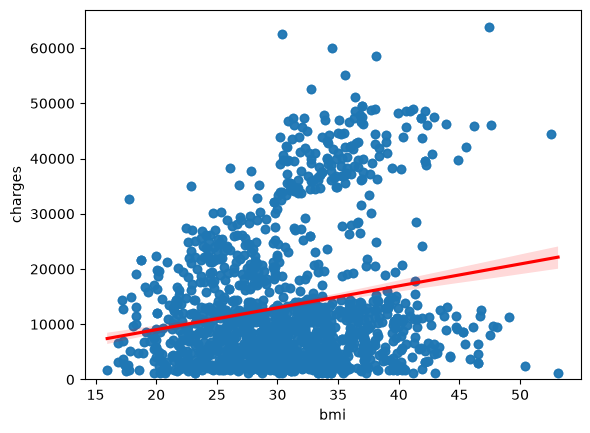

In [64]:
sns.regplot(x="bmi",y="charges",data=df, line_kws={"color":"red"})
plt.ylim(0,)

<Axes: xlabel='smoker', ylabel='charges'>

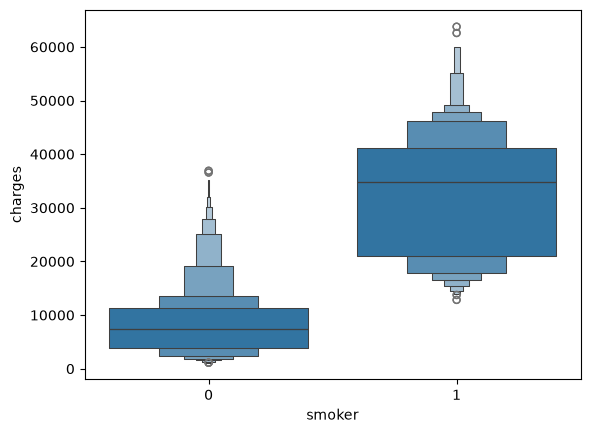

In [65]:
sns.boxenplot(x='smoker',y='charges',data=df)

In [66]:
print(df.corr())

                     age    gender       bmi  no_of_childern    smoker  \
age             1.000000 -0.026584  0.112859        0.037126 -0.022290   
gender         -0.026584  1.000000  0.042766        0.015693  0.083125   
bmi             0.112859  0.042766  1.000000       -0.001642  0.011824   
no_of_childern  0.037126  0.015693 -0.001642        1.000000  0.007016   
smoker         -0.022290  0.083125  0.011824        0.007016  1.000000   
region         -0.006969  0.022360  0.271200       -0.025594  0.053839   
charges         0.298892  0.062959  0.199906        0.066551  0.789141   

                  region   charges  
age            -0.006969  0.298892  
gender          0.022360  0.062959  
bmi             0.271200  0.199906  
no_of_childern -0.025594  0.066551  
smoker          0.053839  0.789141  
region          1.000000  0.054018  
charges         0.054018  1.000000  


# Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.


In [67]:
X = df[['smoker']]
Y = df[['charges']]
lm= LinearRegression()
lm.fit(X,Y)
print(lm.score(X, Y))

0.6227430402464125


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model. You should see an improvement in the performance.


In [76]:
Z = df[['age', 'gender', 'bmi', 'no_of_childern','smoker','region']]
lm.fit(Z,Y)
print(lm.score(Z,Y))

0.7505888664568174


In [78]:
Input = [
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(include_bias=False)),
    ('model',LinearRegression())
]
pipe = Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe = pipe.predict(Z)
print(r2_score(Y,ypipe))

0.8453719105568606


# Model Refinement

Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [79]:
x_train, x_test, y_train, y_test = train_test_split(
    Z,Y, test_size=0.2,random_state=1
)

In [81]:
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))

0.7254198858412229


In [82]:
pr = PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train)
x_test_pr=pr.transform(x_test)
RidgeModel.fit(x_train_pr,y_train)
y_hat=RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.8208413195172286
